In [1]:
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
import os
import multiprocessing as mp

print("os.cpu_count():", os.cpu_count())
print("multiprocessing.cpu_count():", mp.cpu_count())

os.cpu_count(): 8
multiprocessing.cpu_count(): 8


## Config

Binary: `mod_alg_mass_simulate` (custom rules CUST1–5, original row-0 placement, all robots start green)

Output format (stdout):
```
rows cols
n
[[initial_grid]], [[final_grid]], num_r, num_g, num_b, steps, label
...
```
We parse `label` (last field, 1=success) to compute the success rate.

In [3]:
CPP_DIR = Path("../cpp")
BINARY  = CPP_DIR / "mod_alg_mass_simulate"
OUT_DIR = Path("../output/mod_alg")
OUT_DIR.mkdir(parents=True, exist_ok=True)

A_VALUES = list(range(15, 26))   # columns (grid width)
B_VALUES = list(range(15, 26))   # rows    (grid height)
N_SIMULATIONS = 10_000

In [4]:
def run_single(a: int, b: int, n: int) -> float:
    """
    Run ./mod_alg_mass_simulate a b n and return success percentage.
    The binary prints to stdout; label is the last comma-separated field on each
    simulation line (1 = success, 0 = failure).
    """
    result = subprocess.run(
        [str(BINARY), str(a), str(b), str(n)],
        cwd=str(CPP_DIR),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        check=True,
    )

    success_count = 0
    # skip first two header lines ("rows cols" and "n")
    for line in result.stdout.strip().splitlines()[2:]:
        line = line.strip()
        if not line:
            continue
        label = int(line.split(",")[-1].strip())
        success_count += label

    return 100.0 * success_count / n

In [5]:
# Quick sanity check on a small grid before launching the full run
pct = run_single(5, 5, 100)
print(f"5x5 sanity check: {pct:.1f}% success over 100 sims")

5x5 sanity check: 100.0% success over 100 sims


In [6]:
# --- Parallel execution ---
heatmap = np.zeros((len(B_VALUES), len(A_VALUES)), dtype=float)
tasks = {}

print(f"Submitting {len(A_VALUES) * len(B_VALUES)} jobs ({N_SIMULATIONS} sims each)...")

with ProcessPoolExecutor(max_workers=8) as executor:
    for j, b in enumerate(B_VALUES):
        for i, a in enumerate(A_VALUES):
            fut = executor.submit(run_single, a, b, N_SIMULATIONS)
            tasks[fut] = (i, j, a, b)

    for fut in as_completed(tasks):
        i, j, a, b = tasks[fut]
        pct = fut.result()
        heatmap[j, i] = pct
        print(f"  a={a}, b={b} -> {pct:.2f}%")

Submitting 121 jobs (10000 sims each)...
  a=15, b=15 -> 100.00%
  a=16, b=15 -> 100.00%
  a=17, b=15 -> 100.00%
  a=18, b=15 -> 100.00%
  a=19, b=15 -> 100.00%
  a=20, b=15 -> 100.00%
  a=21, b=15 -> 100.00%
  a=22, b=15 -> 100.00%
  a=15, b=16 -> 100.00%
  a=16, b=16 -> 100.00%
  a=17, b=16 -> 100.00%
  a=23, b=15 -> 100.00%
  a=18, b=16 -> 100.00%
  a=24, b=15 -> 100.00%
  a=19, b=16 -> 100.00%
  a=25, b=15 -> 100.00%
  a=20, b=16 -> 100.00%
  a=21, b=16 -> 100.00%
  a=15, b=17 -> 100.00%
  a=16, b=17 -> 100.00%
  a=22, b=16 -> 100.00%
  a=23, b=16 -> 100.00%
  a=17, b=17 -> 100.00%
  a=24, b=16 -> 100.00%
  a=25, b=16 -> 100.00%
  a=18, b=17 -> 100.00%
  a=19, b=17 -> 100.00%
  a=20, b=17 -> 100.00%
  a=21, b=17 -> 100.00%
  a=15, b=18 -> 100.00%
  a=22, b=17 -> 100.00%
  a=16, b=18 -> 100.00%
  a=23, b=17 -> 100.00%
  a=17, b=18 -> 100.00%
  a=24, b=17 -> 100.00%
  a=18, b=18 -> 100.00%
  a=25, b=17 -> 100.00%
  a=19, b=18 -> 100.00%
  a=20, b=18 -> 100.00%
  a=21, b=18 -> 100.00%

In [7]:
df = pd.DataFrame(heatmap, index=B_VALUES, columns=A_VALUES)
df.index.name   = "b"
df.columns.name = "a"

csv_path = OUT_DIR / f"mod_alg_heatmap_success_{A_VALUES[0]}-{A_VALUES[-1]}x{B_VALUES[0]}-{B_VALUES[-1]}_{N_SIMULATIONS}.csv"
df.to_csv(csv_path)
print("Saved CSV:", csv_path)

Saved CSV: ../output/mod_alg/mod_alg_heatmap_success_15-25x15-25_10000.csv


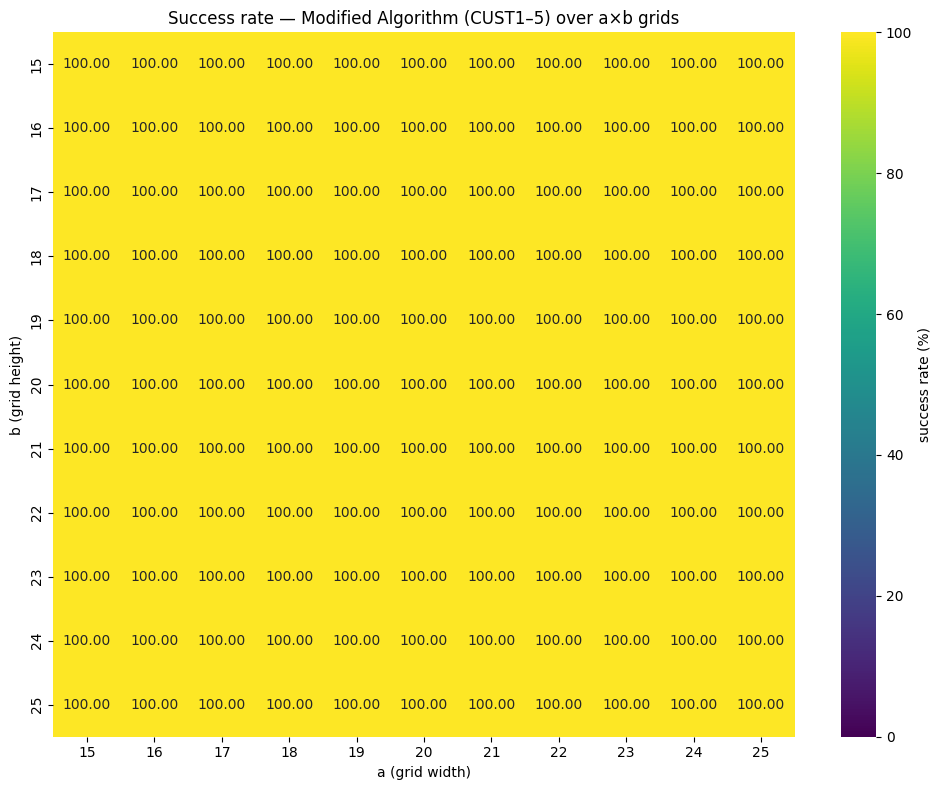

Saved heatmap: ../output/mod_alg/mod_alg_heatmap_15-25x15-25_10000.png


In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0, vmax=100,
    cbar_kws={"label": "success rate (%)"}
)
plt.title("Success rate — Modified Algorithm (CUST1–5) over a×b grids")
plt.xlabel("a (grid width)")
plt.ylabel("b (grid height)")
plt.tight_layout()

png_path = OUT_DIR / f"mod_alg_heatmap_{A_VALUES[0]}-{A_VALUES[-1]}x{B_VALUES[0]}-{B_VALUES[-1]}_{N_SIMULATIONS}.png"
plt.savefig(png_path, dpi=200)
plt.show()
print("Saved heatmap:", png_path)

In [9]:
print(f"Mean success rate : {df.values.mean():.2f}%")
print(f"Std               : {df.values.std():.2f}%")
print(f"Min               : {df.values.min():.2f}%")
print(f"Max               : {df.values.max():.2f}%")

Mean success rate : 100.00%
Std               : 0.00%
Min               : 100.00%
Max               : 100.00%


## Comparison with unmodified baseline

Load the unmodified CSV and plot side-by-side.

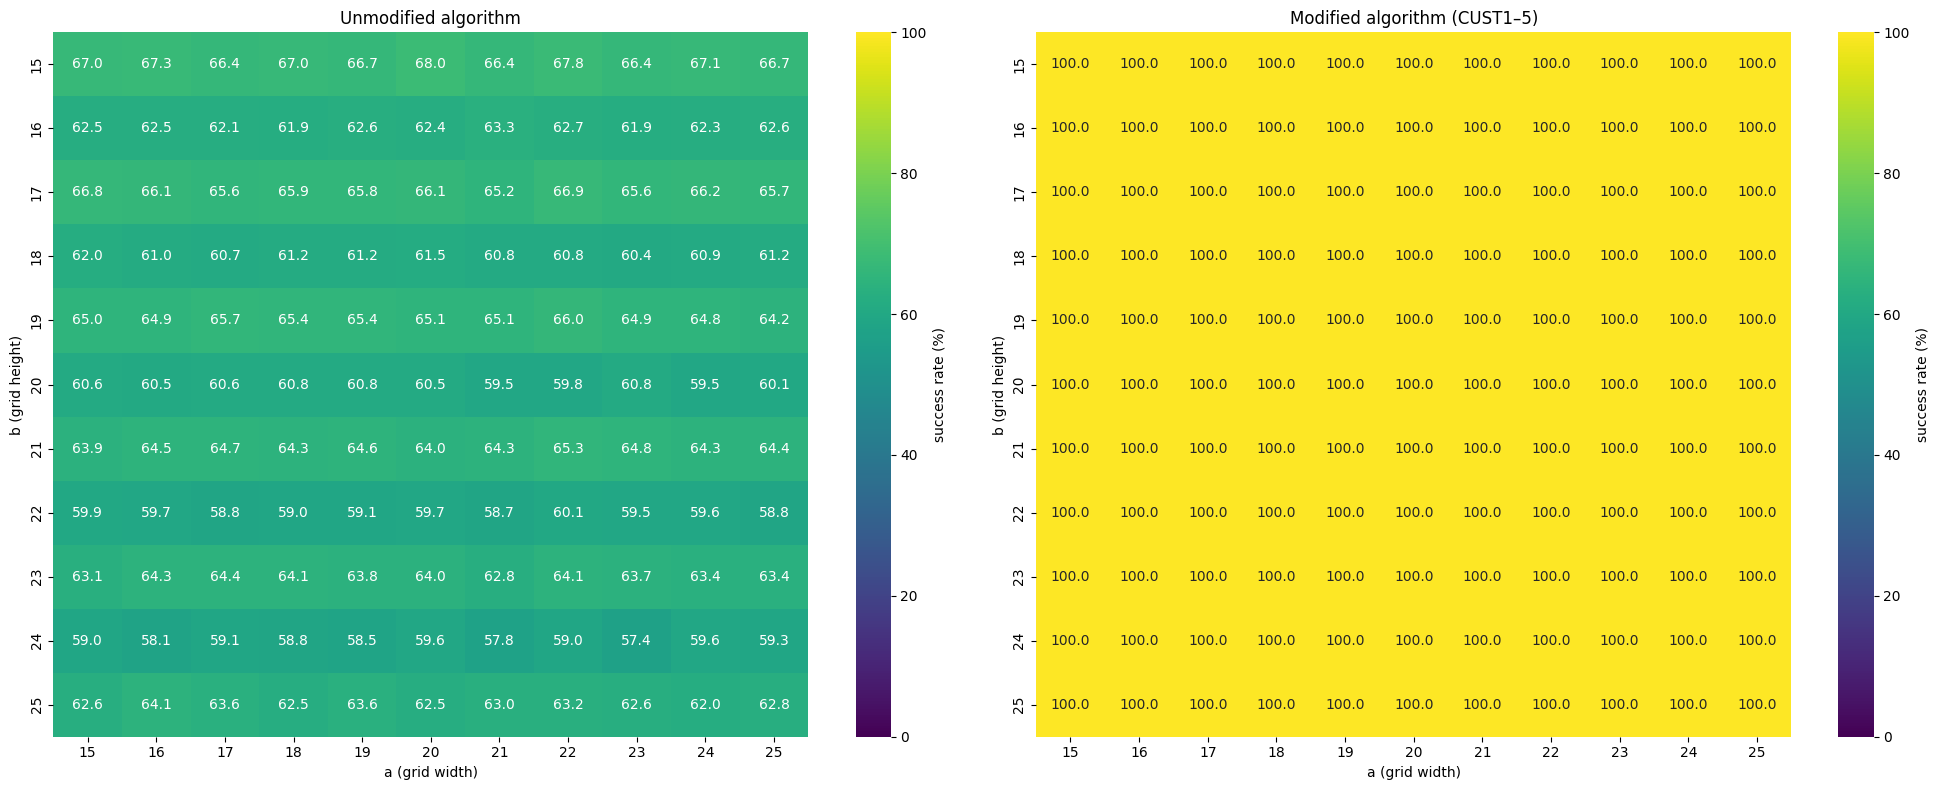

Unmod mean : 62.84%
Mod alg mean: 100.00%


In [10]:
unmod_df = pd.read_csv(
    "../output/unmod/heatmap_success_15-25x15-25_10000.csv",
    index_col=0
)
unmod_df.index   = unmod_df.index.astype(int)
unmod_df.columns = unmod_df.columns.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(unmod_df, annot=True, fmt=".1f", cmap="viridis",
            vmin=0, vmax=100, ax=axes[0],
            cbar_kws={"label": "success rate (%)"})
axes[0].set_title("Unmodified algorithm")
axes[0].set_xlabel("a (grid width)")
axes[0].set_ylabel("b (grid height)")

sns.heatmap(df, annot=True, fmt=".1f", cmap="viridis",
            vmin=0, vmax=100, ax=axes[1],
            cbar_kws={"label": "success rate (%)"})
axes[1].set_title("Modified algorithm (CUST1–5)")
axes[1].set_xlabel("a (grid width)")
axes[1].set_ylabel("b (grid height)")

plt.tight_layout()
plt.savefig(OUT_DIR / "comparison_unmod_vs_mod_alg.png", dpi=200)
plt.show()

print(f"Unmod mean : {unmod_df.values.mean():.2f}%")
print(f"Mod alg mean: {df.values.mean():.2f}%")